Практическая работа №2


1 задание

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')

print("Данные успешно загружены!")
print(f"Размер таблицы: {df.shape}")

Данные успешно загружены!
Размер таблицы: (891, 12)


2 задание

In [ ]:
rows, cols = df.shape
print(f"Количество строк: {rows}")
print(f"Количество столбцов: {cols}")

print("\nНазвания столбцов:")
for col in df.columns:
    print(f" - {col}")

print("\nИнформация о типах данных:")
df.info()

Количество строк: 891
Количество столбцов: 12

Названия столбцов:
 - PassengerId
 - Survived
 - Pclass
 - Name
 - Sex
 - Age
 - SibSp
 - Parch
 - Ticket
 - Fare
 - Cabin
 - Embarked

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


3 задание

In [ ]:
print("Количество пассажиров по классам:")
print(df['Pclass'].value_counts().sort_index())

Количество пассажиров по классам:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64


In [ ]:
print("\nКоличество пассажиров по полу:")
print(df['Sex'].value_counts())


Количество пассажиров по полу:
Sex
male      577
female    314
Name: count, dtype: int64


In [ ]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Ребёнок (0-12)', 'Подросток (13-18)', 'Взрослый (19-35)', 'Средний возраст (36-60)', 'Пожилой (61+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

print("Количество пассажиров по возрастным группам:")
print(df['AgeGroup'].value_counts().sort_index())

Количество пассажиров по возрастным группам:
AgeGroup
Ребёнок (0-12)              69
Подросток (13-18)           70
Взрослый (19-35)           358
Средний возраст (36-60)    195
Пожилой (61+)               22
Name: count, dtype: int64


In [ ]:
# Средний возраст пассажиров
mean_age = df['Age'].mean()
print(f"\nСредний возраст пассажиров: {mean_age:.2f} лет")


Средний возраст пассажиров: 29.70 лет


In [ ]:
# Медианный возраст
median_age = df['Age'].median()
print(f"Медианный возраст пассажиров: {median_age:.2f} лет")

Медианный возраст пассажиров: 28.00 лет


In [ ]:
# Средняя стоимость билета
mean_fare = df['Fare'].mean()
print(f"Средняя стоимость билета: {mean_fare:.2f}")

Средняя стоимость билета: 32.20


4 задание

In [ ]:
print("Средняя стоимость билета по классам:")
print(df.groupby('Pclass')['Fare'].mean().round(2))

Средняя стоимость билета по классам:
Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64


In [ ]:
# Сравнить средний возраст пассажиров разных классов
print("\nСредний возраст пассажиров по классам:")
print(df.groupby('Pclass')['Age'].mean().round(2))


Средний возраст пассажиров по классам:
Pclass
1    38.23
2    29.88
3    25.14
Name: Age, dtype: float64


In [ ]:
# Сравнить количество мужчин и женщин в каждом классе
print("\nКоличество мужчин и женщин по классам:")
print(df.groupby(['Pclass', 'Sex']).size().unstack(fill_value=0))


Количество мужчин и женщин по классам:
Sex     female  male
Pclass              
1           94   122
2           76   108
3          144   347


In [ ]:
# Определить, в каком классе было больше всего пассажиров
most_passengers_class = df['Pclass'].value_counts().idxmax()
print(f"\nБольше всего пассажиров было в {most_passengers_class} классе.")


Больше всего пассажиров было в 3 классе.


In [ ]:
# Найти самый дорогой билет, определить класс, возраст, пол и факт выживания
max_fare_row = df.loc[df['Fare'].idxmax()]
print("Информация о самом дорогом билете:")
print(f"Стоимость билета: {max_fare_row['Fare']}")
print(f"Класс: {max_fare_row['Pclass']}")
print(f"Возраст: {max_fare_row['Age']}")
print(f"Пол: {max_fare_row['Sex']}")
print(f"Выжил: {'Да' if max_fare_row['Survived'] == 1 else 'Нет'}")

Информация о самом дорогом билете:
Стоимость билета: 512.3292
Класс: 1
Возраст: 35.0
Пол: female
Выжил: Да


5 задание

In [ ]:
survived_counts = df['Survived'].value_counts()
print("Общее количество выживших и погибших:")
print(f"Погибшие (0): {survived_counts[0]}")
print(f"Выжившие (1): {survived_counts[1]}")

Общее количество выживших и погибших:
Погибшие (0): 549
Выжившие (1): 342


In [ ]:
# 2. Сравнить выживаемость мужчин и женщин
print("\nВыживаемость по полу:")
survival_by_sex = df.groupby('Sex')['Survived'].mean().round(3)
print(survival_by_sex)
print("\n(Доля выживших: 1.0 = 100%)")


Выживаемость по полу:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

(Доля выживших: 1.0 = 100%)


In [ ]:
# 3. Сравнить выживаемость мужчин и женщин для каждого класса
print("\nВыживаемость по классу и полу:")
survival_by_class_sex = df.groupby(['Pclass', 'Sex'])['Survived'].mean().round(3)
print(survival_by_class_sex)


Выживаемость по классу и полу:
Pclass  Sex   
1       female    0.968
        male      0.369
2       female    0.921
        male      0.157
3       female    0.500
        male      0.135
Name: Survived, dtype: float64


In [ ]:
# 4. Определить, какая группа пассажиров имела наибольшую долю выживших
# Группируем по классу и полу, считаем долю выживших
survival_group = df.groupby(['Pclass', 'Sex'])['Survived'].mean()
best_group = survival_group.idxmax()
best_value = survival_group.max()

print(f"\nНаибольшая доля выживших: {best_value:.3f}")
print(f"Это группа: Класс {best_group[0]}, Пол: {best_group[1]}")


Наибольшая доля выживших: 0.968
Это группа: Класс 1, Пол: female


6 задание

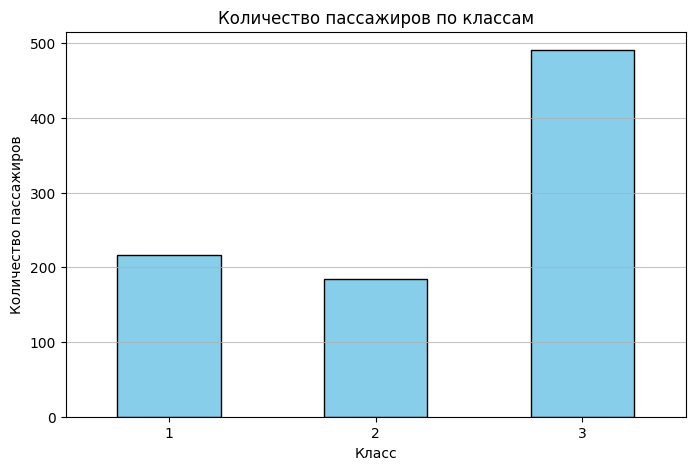

In [ ]:
plt.figure(figsize=(8, 5))
df['Pclass'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Количество пассажиров по классам')
plt.xlabel('Класс')
plt.ylabel('Количество пассажиров')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.75)
plt.show()

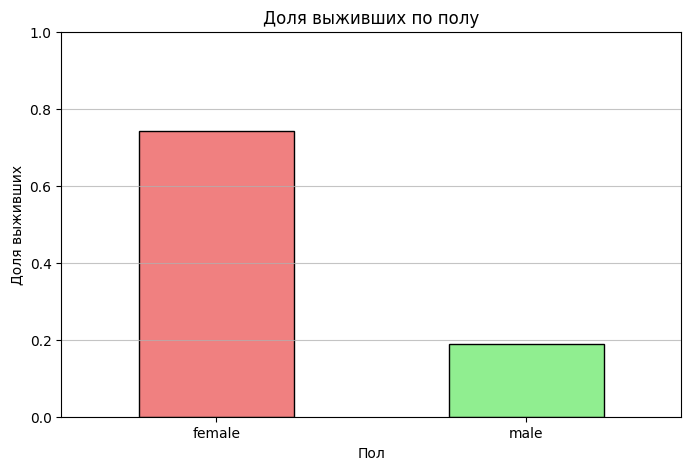

In [ ]:
# График выживаемости по полу
plt.figure(figsize=(8, 5))
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['lightcoral', 'lightgreen'], edgecolor='black')
plt.title('Доля выживших по полу')
plt.xlabel('Пол')
plt.ylabel('Доля выживших')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.75)
plt.show()

как возраст влияет на выживаемость?

In [ ]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                        labels=['Дети (0-12)', 'Подростки (13-18)',
                                'Молодые (19-35)', 'Взрослые (36-60)',
                                'Пожилые (61+)'])

print("Выживаемость по возрастным группам:")
age_survival = df.groupby('AgeGroup')['Survived'].agg(['mean', 'count']).round(3)
age_survival.columns = ['Доля выживших', 'Количество пассажиров']
print(age_survival)

Выживаемость по возрастным группам:
                   Доля выживших  Количество пассажиров
AgeGroup                                               
Дети (0-12)                0.580                     69
Подростки (13-18)          0.429                     70
Молодые (19-35)            0.383                    358
Взрослые (36-60)           0.400                    195
Пожилые (61+)              0.227                     22


/tmp/ipykernel_399/1427187693.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('AgeGroup')['Survived'].agg(['mean', 'count']).round(3)


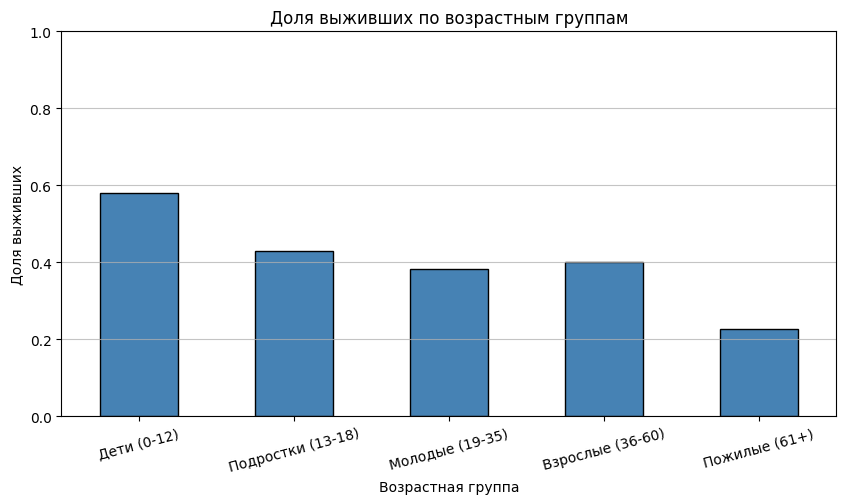

In [ ]:
plt.figure(figsize=(10, 5))
age_survival['Доля выживших'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Доля выживших по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Доля выживших')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.75)
plt.show()